In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset('titanic')
tasa_global = titanic['survived'].mean()


## Diapositiva 1 — El Titanic tuvo una tasa de mortalidad alta

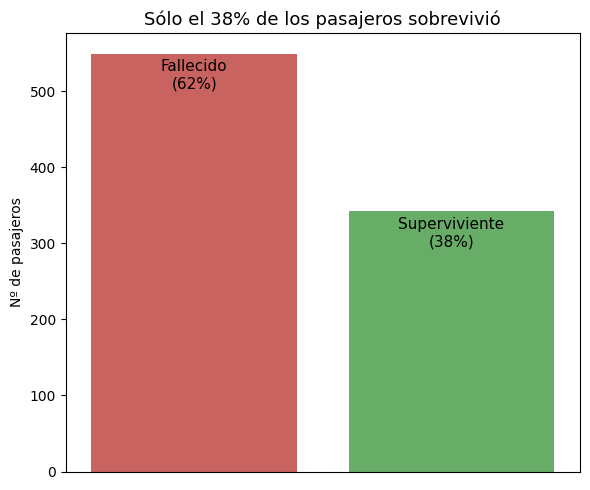

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(data=titanic, x='survived', hue='survived',
              order=[0, 1], palette=['#d9534f', '#5cb85c'],
              legend=False, ax=ax)
for bar, label in zip(ax.patches, ['Fallecido\n(62%)', 'Superviviente\n(38%)']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 50,
            label, ha='center', va='bottom', fontsize=11)
ax.set_title('Sólo el 38% de los pasajeros sobrevivió', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Nº de pasajeros')
ax.set_xticks([])
plt.tight_layout()
plt.show()


## Diapositiva 2 — Los datos apoyan 'mujeres y niños primero'

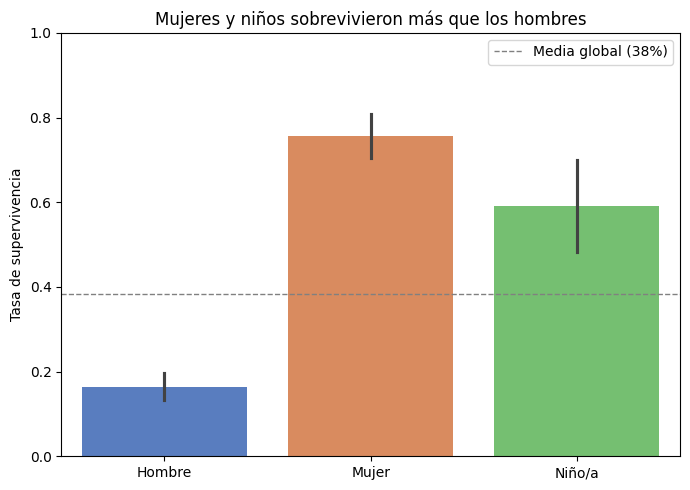

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=titanic, x='who', y='survived', hue='who',
            order=['man', 'woman', 'child'],
            palette='muted', legend=False, ax=ax)
ax.set_xticks(range(3))
ax.set_xticklabels(['Hombre', 'Mujer', 'Niño/a'])
ax.set_title('Mujeres y niños sobrevivieron más que los hombres', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Tasa de supervivencia')
ax.set_ylim(0, 1)
ax.axhline(tasa_global, linestyle='--', color='gray', linewidth=1,
           label=f'Media global ({tasa_global:.0%})')
ax.legend()
plt.tight_layout()
plt.show()


## Diapositiva 3 — La clase tuvo una influencia significativa

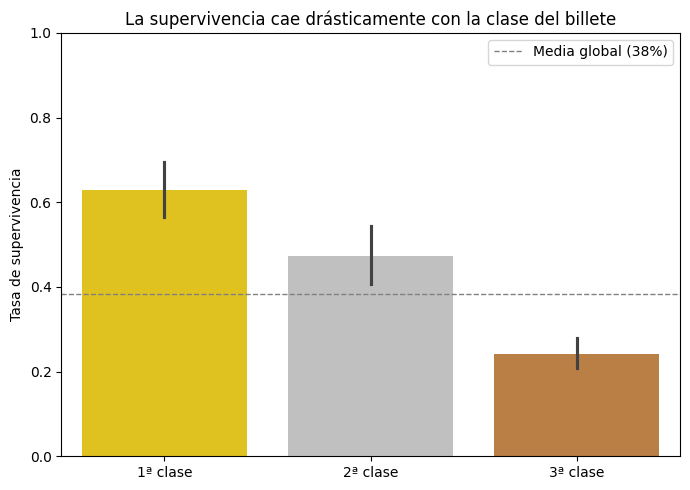

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=titanic, x='pclass', y='survived', hue='pclass',
            palette=['gold', 'silver', '#cd7f32'],
            legend=False, ax=ax)
ax.set_xticks(range(3))
ax.set_xticklabels(['1ª clase', '2ª clase', '3ª clase'])
ax.set_title('La supervivencia cae drásticamente con la clase del billete', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Tasa de supervivencia')
ax.set_ylim(0, 1)
ax.axhline(tasa_global, linestyle='--', color='gray', linewidth=1,
           label=f'Media global ({tasa_global:.0%})')
ax.legend()
plt.tight_layout()
plt.show()


## Diapositiva 4 — La clase explica las diferencias entre mujeres y niños

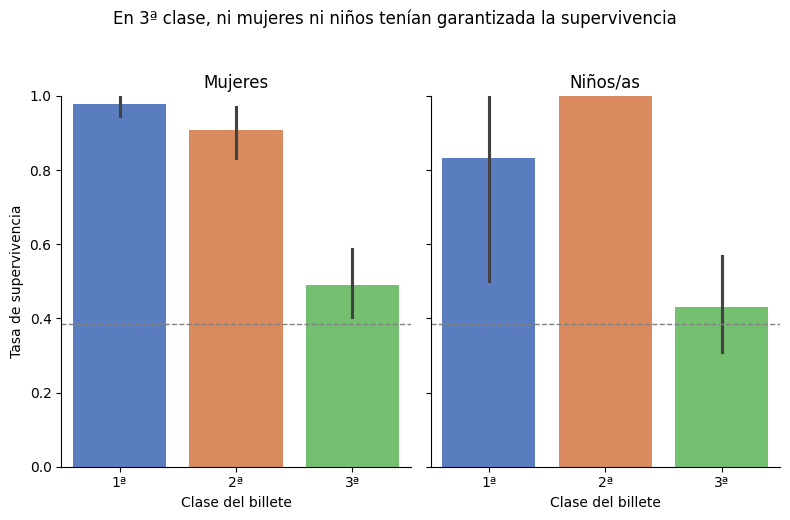

In [5]:
g = sns.catplot(
    data    = titanic[titanic['who'] != 'man'],
    kind    = 'bar',
    x       = 'pclass',
    y       = 'survived',
    hue     = 'pclass',
    col     = 'who',
    palette = 'muted',
    legend  = False,
    height  = 5, aspect = 0.8
)
for ax, titulo in zip(g.axes.flat, ['Mujeres', 'Niños/as']):
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Clase del billete')
    ax.set_ylabel('Tasa de supervivencia')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['1ª', '2ª', '3ª'])
    ax.set_ylim(0, 1)
    ax.axhline(tasa_global, linestyle='--', color='gray', linewidth=1)
g.figure.suptitle('En 3ª clase, ni mujeres ni niños tenían garantizada la supervivencia',
                  y=1.03, fontsize=12)
plt.tight_layout()
plt.show()


## Diapositiva 5 — El puerto parece influir, pero lo explica la clase

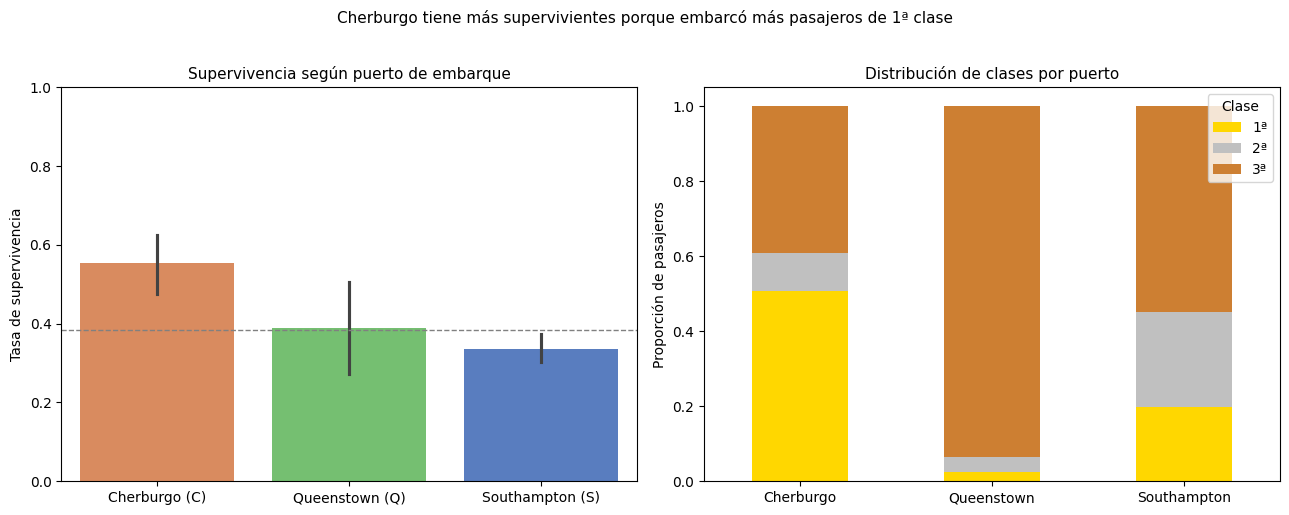

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=titanic, x='embarked', y='survived', hue='embarked',
            order=['C', 'Q', 'S'], palette='muted', legend=False, ax=axes[0])
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['Cherburgo (C)', 'Queenstown (Q)', 'Southampton (S)'])
axes[0].set_title('Supervivencia según puerto de embarque', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Tasa de supervivencia')
axes[0].set_ylim(0, 1)
axes[0].axhline(tasa_global, linestyle='--', color='gray', linewidth=1)

clase_por_puerto = pd.crosstab(titanic['embarked'], titanic['pclass'], normalize='index')
clase_por_puerto.plot(kind='bar', stacked=True,
                      color=['gold', 'silver', '#cd7f32'], ax=axes[1])
axes[1].set_title('Distribución de clases por puerto', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Proporción de pasajeros')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['Cherburgo', 'Queenstown', 'Southampton'], rotation=0)
axes[1].legend(title='Clase', labels=['1ª', '2ª', '3ª'])

plt.suptitle('Cherburgo tiene más supervivientes porque embarcó más pasajeros de 1ª clase',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
